# Cell Type Proportions by Lesion Status

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sp
from plotnine import *
import mizani

from matplotlib import pyplot as plt
from tqdm.auto import tqdm
#from sctoolkit.proportions import dirichletreg, bin_pval, get_proportions_per_channel, plot_proportion_barplot
from statsmodels.stats.multitest import multipletests

In [2]:
%load_ext rpy2.ipython

In [3]:
import sys

sys.path.append('/home/gokcen/Code/sctoolkit/')

In [4]:
from sctoolkit.proportions import dirichletreg, bin_pval, get_proportions_per_channel, plot_proportion_barplot

In [5]:
sc.set_figure_params(dpi=90)

In [11]:
# Read the data
adata = sc.read('../AtopicDermatitis-raw.h5ad')
ad = adata[(~adata.obs.ind_id.isin(['BCH04', 'BCH07']))].copy()

## Coarse Cell type boxplot

In [12]:
# Copy the observations DataFrame
df = ad.obs.copy()
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type', 'disease_lesional']).size().reset_index(name='count')

# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')

# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type']):
    proportion_df['Cell type'] = pd.Categorical(
        proportion_df['Cell type'],
        categories=ad.obs['Cell type'].cat.categories,
        ordered=True
    )

# Print the DataFrame to verify its contents
print(proportion_df)

          channel                Cell type disease_lesional  count  \
0     Healthy1-H1            Keratinocytes          Healthy   8998   
1     Healthy1-H1            Keratinocytes     Non-lesional      0   
2     Healthy1-H1            Keratinocytes         Lesional      0   
3     Healthy1-H1  Cornified keratinocytes          Healthy     26   
4     Healthy1-H1  Cornified keratinocytes     Non-lesional      0   
...           ...                      ...              ...    ...   
1579     MGH110-L                   Plasma     Non-lesional      0   
1580     MGH110-L                   Plasma         Lesional     67   
1581     MGH110-L                     T/NK          Healthy      0   
1582     MGH110-L                     T/NK     Non-lesional      0   
1583     MGH110-L                     T/NK         Lesional   1443   

      total_in_group  proportion  total_count  
0              14331    0.627870        14331  
1                  0         NaN        14331  
2              

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


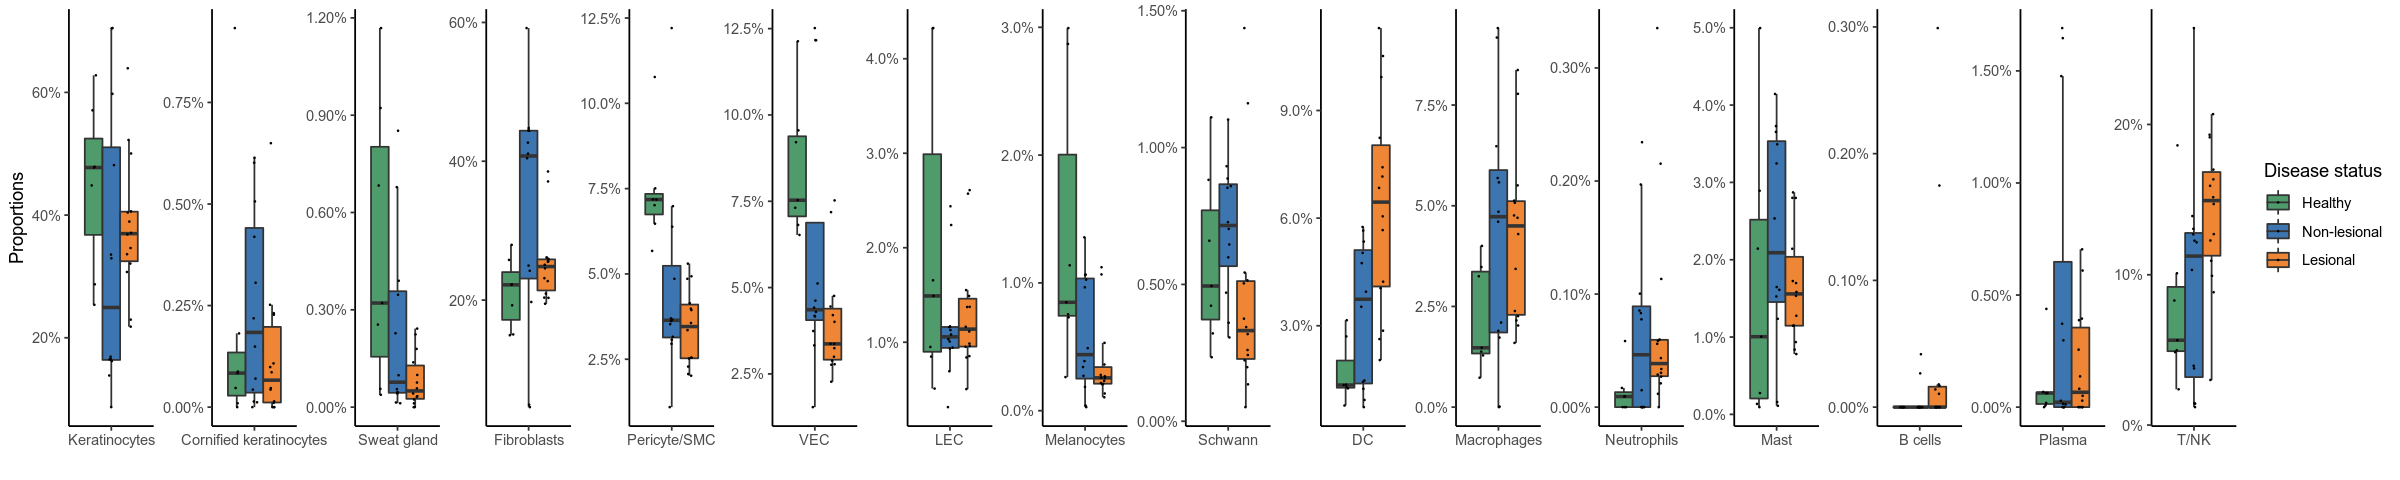

In [13]:
%%R -i proportion_df -w 20 -h 4 -u in -r 120
library(ggplot2)
library(scales)  # for percent formatting

# Plot: using disease_lesional to fill the boxplots
g <- ggplot(proportion_df, aes(x=`Cell type`, y=proportion, fill=disease_lesional)) + 
  geom_boxplot(position='dodge', notch=FALSE, outlier.shape = NA) +
  geom_point(aes(group=disease_lesional), 
             position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +
  facet_wrap(~`Cell type`, scales='free', nrow=1) + 
  theme_classic() + 
  theme(strip.background=element_blank(), strip.text=element_blank()) + 
  scale_fill_manual(values=c('#4F9B6C', '#3C75AF', '#EF8636')) + 
  scale_y_continuous(labels = percent) +
  labs(y='Proportions', x='', fill='Disease status')
g

## Keratinocytes boxplot

In [9]:

# Copy the observations DataFrame
df = ad.obs.copy()
df = df[df['Cell type'].isin(['Keratinocytes','Cornified keratinocytes'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )

kera_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['KC cycling','KC 1','KC 4','Cornified KC 1','Cornified KC 2','KC 2','KC 3','KC 5'])]
kera_pdf

NameError: name 'ad' is not defined

In [14]:
%%R -i kera_pdf -w 12 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(kera_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of Keratinocytes (%)', x='', fill='Disease status')
)
g

NameError: name 'kera_pdf' is not defined

## DC boxplots

In [20]:
# Copy the observations DataFrame
df = ad.obs.copy()
df = df[df['Cell type granular'].isin(['DC1', 'Proliferating DC1', 'DC2', 'DC2 CD83+', 'Proliferating DC2', 'Langerhans DC', 'DC MMP12 hi LAMP3 lo', 'mmDC LAMP3+', 'DC MMP9+CCR7+'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
dc_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['DC MMP12+','mmDC','DC 2 CD83+','DC IL1B+','DC 1','DC 1 cycling','DC 2','DC 2 cycling','LDC'])]

,channel,Cell type granular v2,disease_lesional,count,total_in_group,proportion,total_count
150,Healthy1-H1,DC 1,Healthy,34,180,0.188889,180
151,Healthy1-H1,DC 1,Non-lesional,0,0,NaN,180
152,Healthy1-H1,DC 1,Lesional,0,0,NaN,180
153,Healthy1-H1,DC 1 cycling,Healthy,4,180,0.022222,180
154,Healthy1-H1,DC 1 cycling,Non-lesional,0,0,NaN,180
155,Healthy1-H1,DC 1 cycling,Lesional,0,0,NaN,180
156,Healthy1-H1,DC 2,Healthy,73,180,0.405556,180
157,Healthy1-H1,DC 2,Non-lesional,0,0,NaN,180
158,Healthy1-H1,DC 2,Lesional,0,0,NaN,180
159,Healthy1-H1,DC 2 CD83+,Healthy,55,180,0.305556,180


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 12 x 4 in image



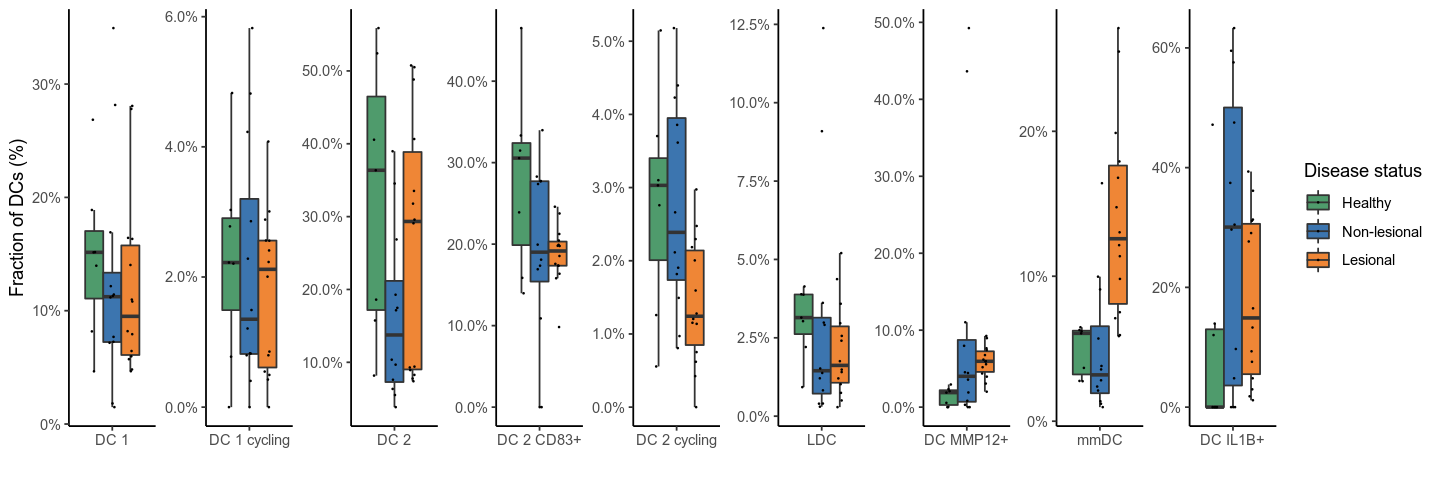

In [45]:
%%R -i dc_pdf -w 12 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(dc_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of DCs (%)', x='', fill='Disease status')
)
g

## Macrophage boxplots

In [126]:
ad[ad.obs['Cell type']=='Macrophages'].obs['Cell type granular v2'].unique()

['MΦ SPP1+', 'MΦ C1QA hi', 'MΦ STAB1 hi', 'MΦ FNIP2 hi', 'MΦ EGR1+', 'MΦ IL1B+']
Categories (6, object): ['MΦ IL1B+', 'MΦ FNIP2 hi', 'MΦ EGR1+', 'MΦ C1QA hi', 'MΦ STAB1 hi', 'MΦ SPP1+']

In [30]:
# Copy the observations DataFrame
df = ad.obs.copy()
df = df[df['Cell type'].isin(['Macrophages'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
macrophage_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['MΦ SPP1+', 'MΦ C1QA hi', 'MΦ STAB1 hi', 'MΦ FNIP2 hi', 'MΦ EGR1+', 'MΦ IL1B+'])]
macrophage_pdf

,channel,Cell type granular v2,disease_lesional,count,total_in_group,proportion,total_count
177,Healthy1-H1,MΦ IL1B+,Healthy,0,184,0.000000,184
178,Healthy1-H1,MΦ IL1B+,Non-lesional,0,0,NaN,184
179,Healthy1-H1,MΦ IL1B+,Lesional,0,0,NaN,184
180,Healthy1-H1,MΦ FNIP2 hi,Healthy,7,184,0.038043,184
181,Healthy1-H1,MΦ FNIP2 hi,Non-lesional,0,0,NaN,184
182,Healthy1-H1,MΦ FNIP2 hi,Lesional,0,0,NaN,184
183,Healthy1-H1,MΦ EGR1+,Healthy,12,184,0.065217,184
184,Healthy1-H1,MΦ EGR1+,Non-lesional,0,0,NaN,184
185,Healthy1-H1,MΦ EGR1+,Lesional,0,0,NaN,184
186,Healthy1-H1,MΦ C1QA hi,Healthy,146,184,0.793478,184


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 12 x 4 in image



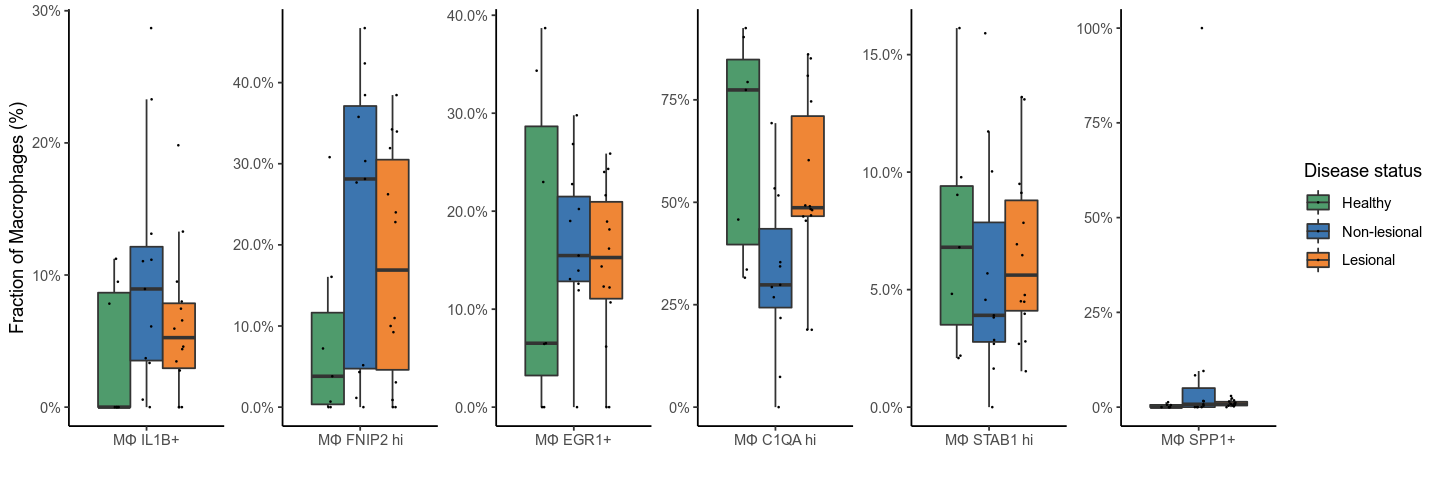

In [31]:
%%R -i dc_pdf -w 12 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(macrophage_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of Macrophages (%)', x='', fill='Disease status')
)
ggsave('tanvi_figures/macrophage_ct_boxplot.pdf', useDingbats=F)
#ggsave('figures/figure01/proportions-boxplot-keratinocytes.pdf', useDingbats=F)
g

## Fig 4 - T/NK cells

Fig 4f

In [52]:
for i in ad[ad.obs['Cell type']=='B cells'].obs['Cell type granular v2'].unique():
    print(f"'{i}',")

'B Naive/Mem',


In [111]:
# Copy the observations DataFrame
df = ad.obs.copy()
df = df[df['Cell type'].isin(['T/NK'])]

# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
TNK_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['T CREM lo FOS lo',
'CD8+ CTL IFNG hi',
'T FOS hi',
'T CREM hi',
'Treg',
'γδ T',
'Treg cycling',
'ILC',
'NK',
'CD8+ CTL',
'T FOS hi cycling',
'ILC cycling'])]

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 15 x 4 in image



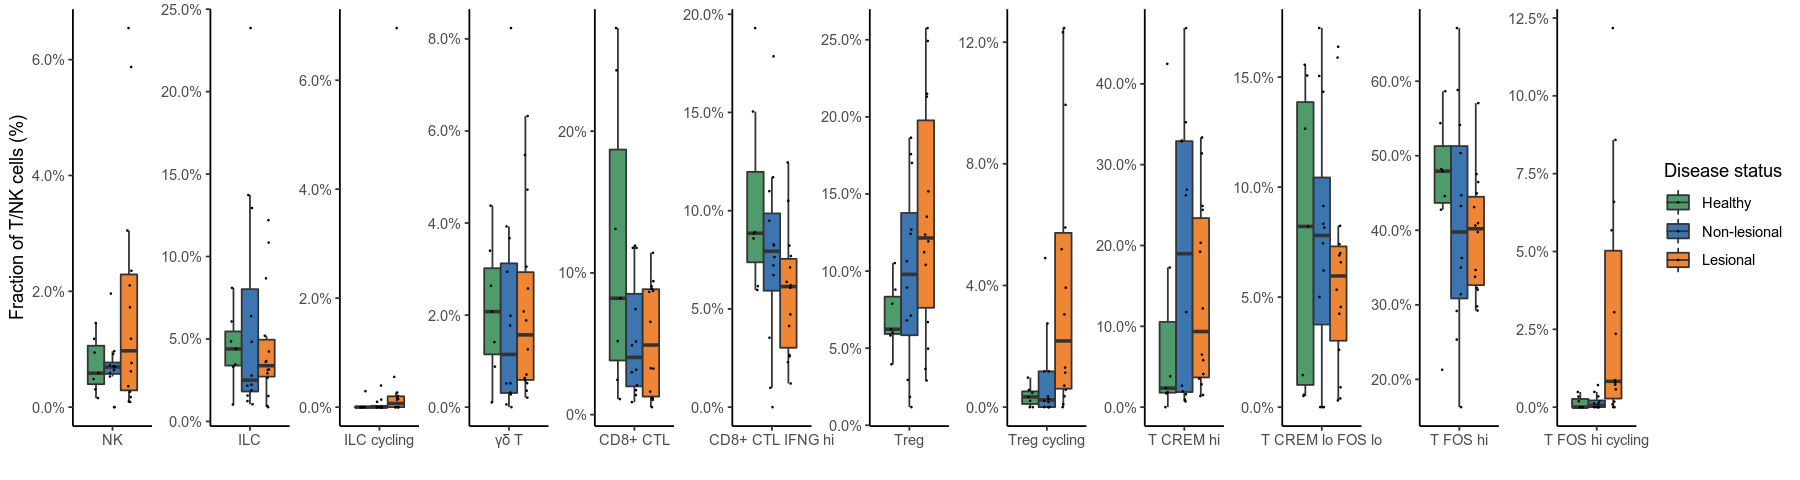

In [112]:
%%R -i TNK_pdf -w 15 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(dc_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of T/NK cells (%)', x='', fill='Disease status')
)

g

In [122]:
# Copy the observations DataFrame
df = ad.obs.copy()
df = df[df['Cell type'].isin(['Plasma'])]

# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
plasma_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['Plasma IgG',
'Plasmablast',
'Plasma IgA'])]

,channel,Cell type granular v2,disease_lesional,count,total_in_group,proportion,total_count
213,Healthy1-H1,Plasmablast,Healthy,0,9,0.000000,9
214,Healthy1-H1,Plasmablast,Non-lesional,0,0,NaN,9
215,Healthy1-H1,Plasmablast,Lesional,0,0,NaN,9
216,Healthy1-H1,Plasma IgA,Healthy,9,9,1.000000,9
217,Healthy1-H1,Plasma IgA,Non-lesional,0,0,NaN,9
218,Healthy1-H1,Plasma IgA,Lesional,0,0,NaN,9
219,Healthy1-H1,Plasma IgG,Healthy,0,9,0.000000,9
220,Healthy1-H1,Plasma IgG,Non-lesional,0,0,NaN,9
221,Healthy1-H1,Plasma IgG,Lesional,0,0,NaN,9
471,Healthy2-H2,Plasmablast,Healthy,0,8,0.000000,8


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 5 x 4 in image



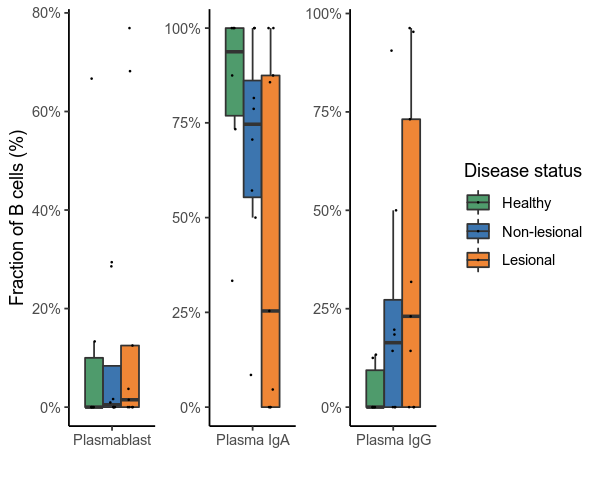

In [64]:
%%R -i dc_pdf -w 5 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(dc_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of B cells (%)', x='', fill='Disease status')
)
g

In [84]:
# Copy the observations DataFrame
df = ad.obs.copy()
df = df[df['Cell type'].isin(['B cells'])]

# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
bcell_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['B Naive/Mem'])]


,channel,Cell type granular v2,disease_lesional,count,total_in_group,proportion,total_count
210,Healthy1-H1,B Naive/Mem,Healthy,0,0,NaN,0
211,Healthy1-H1,B Naive/Mem,Non-lesional,0,0,NaN,0
212,Healthy1-H1,B Naive/Mem,Lesional,0,0,NaN,0
468,Healthy2-H2,B Naive/Mem,Healthy,0,0,NaN,0
469,Healthy2-H2,B Naive/Mem,Non-lesional,0,0,NaN,0
...,...,...,...,...,...,...,...
8209,MGH108-L2,B Naive/Mem,Non-lesional,0,0,NaN,0
8210,MGH108-L2,B Naive/Mem,Lesional,0,0,NaN,0
8466,MGH110-L,B Naive/Mem,Healthy,0,0,NaN,1
8467,MGH110-L,B Naive/Mem,Non-lesional,0,0,NaN,1


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


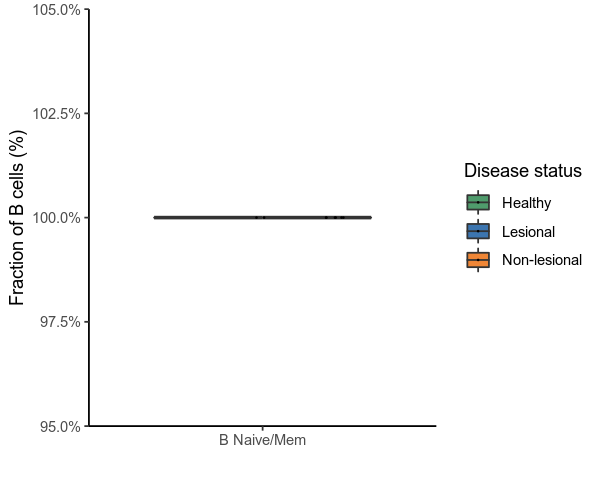

In [85]:
%%R -i bcell_pdf -w 5 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(bcell_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of B cells (%)', x='', fill='Disease status')
)

g

In [9]:
# Copy the observations DataFrame
df = ad.obs.copy()
df = df[df['Cell type'].isin(['Plasma','T/NK','B cells'])]

# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
dc_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['NK','ILC','γδ T','CD8+ CTL','T CREM hi','T CREM lo FOS lo','T FOS hi','Plasmablast','Plasma IgA','B Naive/Mem'])]
dc_pdf

,channel,Cell type granular v2,disease_lesional,count,total_in_group,proportion,total_count
210,Healthy1-H1,B Naive/Mem,Healthy,0,350,0.000000,350
211,Healthy1-H1,B Naive/Mem,Non-lesional,0,0,NaN,350
212,Healthy1-H1,B Naive/Mem,Lesional,0,0,NaN,350
213,Healthy1-H1,Plasmablast,Healthy,0,350,0.000000,350
214,Healthy1-H1,Plasmablast,Non-lesional,0,0,NaN,350
...,...,...,...,...,...,...,...
8506,MGH110-L,T CREM lo FOS lo,Non-lesional,0,0,NaN,1511
8507,MGH110-L,T CREM lo FOS lo,Lesional,77,1511,0.050960,1511
8508,MGH110-L,T FOS hi,Healthy,0,0,NaN,1511
8509,MGH110-L,T FOS hi,Non-lesional,0,0,NaN,1511


In [ ]:
#make this accoridng to each coarse cell type instead - to line it up with dirichlet reg
#run find dirichlet again + eyeball 

In [63]:
ad[ad.obs['Cell type']=='B cells'].obs['Cell type granular v2'].unique()

['B Naive/Mem']
Categories (1, object): ['B Naive/Mem']

## Fig 5 - Fibroblast/Stromal
### Fibroblast

In [66]:
for i in ad[ad.obs['Cell type'].isin(['Fibroblasts'])].obs['Cell type granular v2'].unique():
    print(f"'{i}',")

'FB NGFR+',
'FB papillary',
'FB CPE+',
'FB APOC1+',
'FB CCL19+APOE+',
'FB CDH19+',
'FB reticular',
'FB GDF10+',
'FB dermal papilla',
'FB DPEP1+',
'FB CCL19+IL4I1+',


In [68]:
df = ad.obs.copy()
df = df[df['Cell type']=='Fibroblasts']
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
fib_pdf = proportion_df[proportion_df['Cell type granular v2'].isin([
'FB NGFR+',
'FB papillary',
'FB CPE+',
'FB APOC1+',
'FB CCL19+APOE+',
'FB CDH19+',
'FB reticular',
'FB GDF10+',
'FB dermal papilla',
'FB DPEP1+',
'FB CCL19+IL4I1+'])]

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 15 x 4 in image



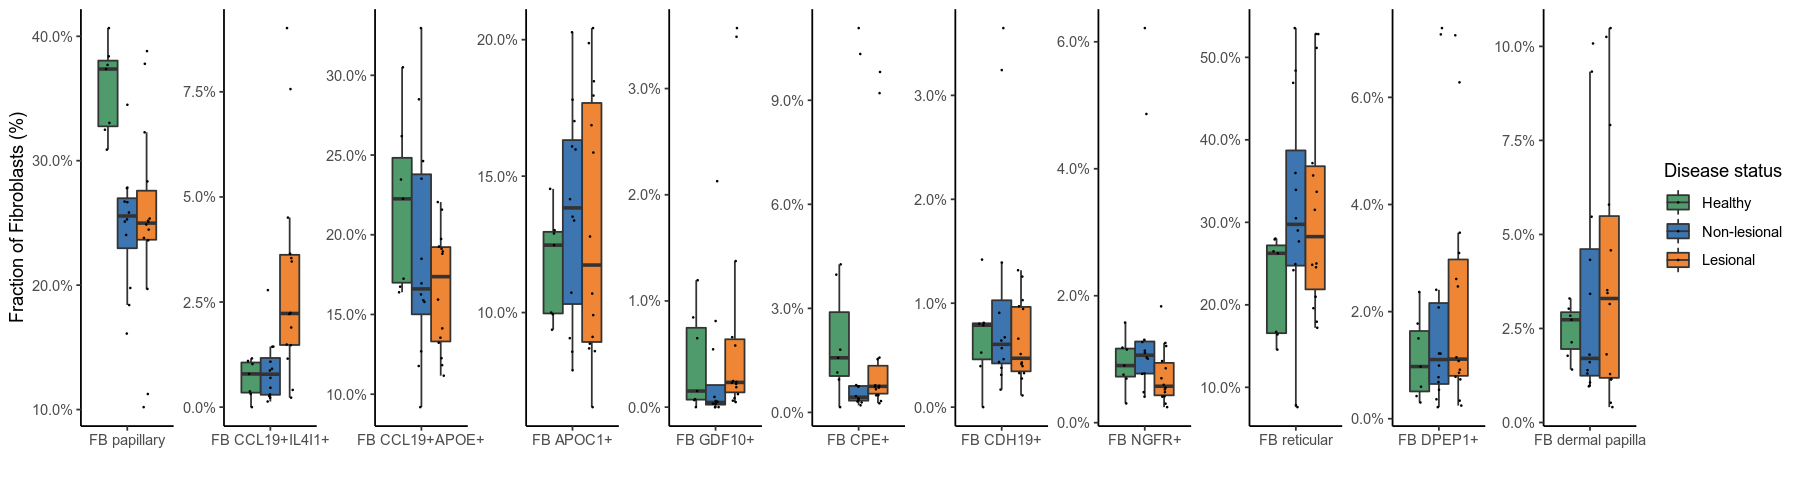

In [69]:
%%R -i fib_pdf -w 15 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(fib_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of Fibroblasts (%)', x='', fill='Disease status')
)
g

### Endothelial

In [85]:
for i in ad[ad.obs['Cell type']=='VEC'].obs['Cell type granular v2'].unique():
    print(f"'{i}',")

'CapEC INSR hi',
'VenEC CCL14 hi',
'VenEC CCL15 hi',
'CapEC FABP4+',
'ArtEC ICAM2 hi',
'VenEC RGS5+ACKR1 hi',
'CapEC RGS5+EDNRB hi',
'ArtEC RGS5+IGFBP3+',
'VenEC IL6+',
'CapEC EDNRB hi',
'CapEC RGS5+FABP4+',
'Cap EC RGS5+EDNRB hi MCAM hi',
'ArtEC SOS1 hi',


In [87]:
df = ad.obs.copy()
df = df[df['Cell type'].isin(['VEC'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
endo_pdf = proportion_df[proportion_df['Cell type granular v2'].isin([
'CapEC INSR hi',
'VenEC CCL14 hi',
'VenEC CCL15 hi',
'CapEC FABP4+',
'ArtEC ICAM2 hi',
'VenEC RGS5+ACKR1 hi',
'CapEC RGS5+EDNRB hi',
'ArtEC RGS5+IGFBP3+',
'VenEC IL6+',
'CapEC EDNRB hi',
'CapEC RGS5+FABP4+',
'Cap EC RGS5+EDNRB hi MCAM hi',
'ArtEC SOS1 hi'])]


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 30 x 4 in image



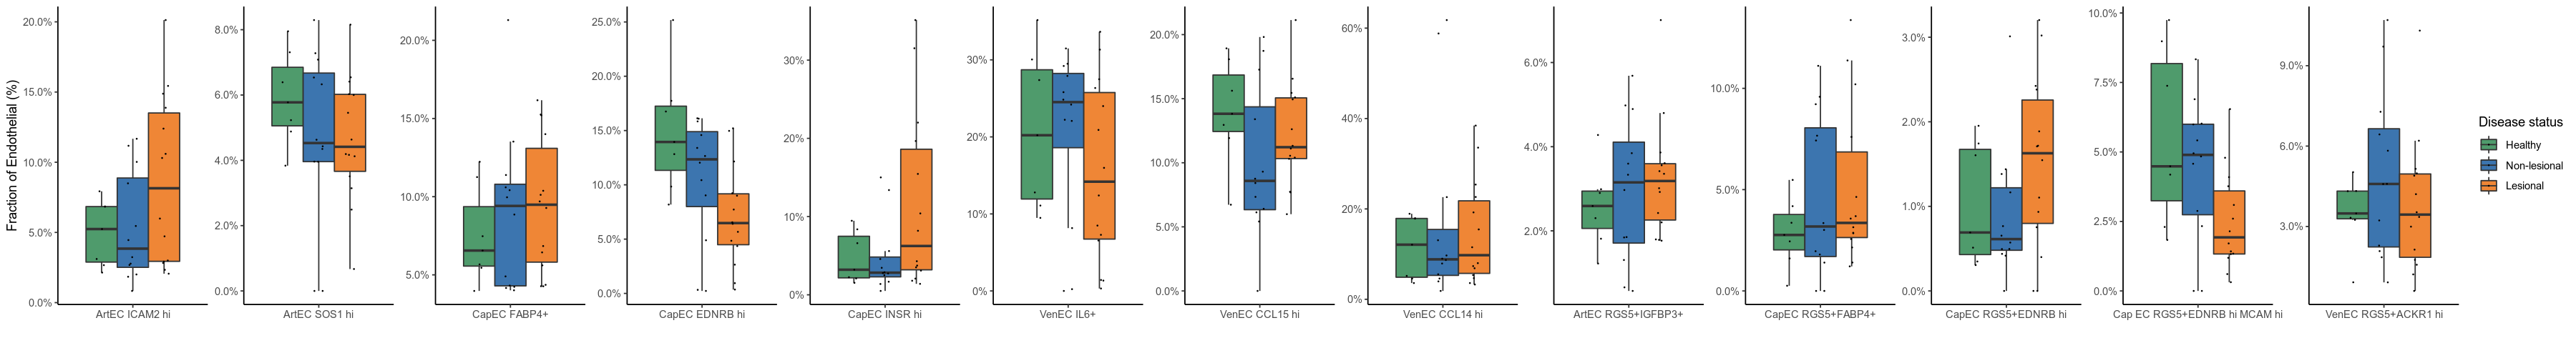

In [88]:
%%R -i endo_pdf -w 30 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(endo_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of Endothelial (%)', x='', fill='Disease status')
)

ggsave('tanvi_figures/VEC_ct_boxplot.pdf', useDingbats=F)
g

### Pericytes/SMC

In [98]:
for i in ad[ad.obs['Cell type']=='Pericyte/SMC'].obs['Cell type granular v2'].unique():
    print(f"'{i}',")

'PE TGFBI+',
'SMC RERGL+',
'PE RGS hi',
'SMC DES+',
'PE/SMC GEM hi',


In [99]:
df = ad.obs.copy()
df = df[df['Cell type granular'].isin(['Pericyte RGS5 lo', 'Pericyte RGS5 hi', 'Pericyte/SMC MYH11-', 'SMC PLN', 'Myocytes'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['channel', 'Cell type granular v2', 'disease_lesional']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['channel', 'disease_lesional'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('channel').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='channel')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(ad.obs['Cell type granular v2']):
    proportion_df['Cell type granular v2'] = pd.Categorical(
        proportion_df['Cell type granular v2'],
        categories=ad.obs['Cell type granular v2'].cat.categories,
        ordered=True
    )
peri_pdf = proportion_df[proportion_df['Cell type granular v2'].isin(['PE TGFBI+',
'SMC RERGL+',
'PE RGS hi',
'SMC DES+',
'PE/SMC GEM hi'])]

,channel,Cell type granular v2,disease_lesional,count,total_in_group,proportion,total_count
72,Healthy1-H1,PE TGFBI+,Healthy,243,1029,0.236152,1029
73,Healthy1-H1,PE TGFBI+,Non-lesional,0,0,NaN,1029
74,Healthy1-H1,PE TGFBI+,Lesional,0,0,NaN,1029
75,Healthy1-H1,PE RGS hi,Healthy,368,1029,0.357629,1029
76,Healthy1-H1,PE RGS hi,Non-lesional,0,0,NaN,1029
77,Healthy1-H1,PE RGS hi,Lesional,0,0,NaN,1029
78,Healthy1-H1,PE/SMC GEM hi,Healthy,73,1029,0.070943,1029
79,Healthy1-H1,PE/SMC GEM hi,Non-lesional,0,0,NaN,1029
80,Healthy1-H1,PE/SMC GEM hi,Lesional,0,0,NaN,1029
81,Healthy1-H1,SMC RERGL+,Healthy,336,1029,0.326531,1029


/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 8 x 4 in image



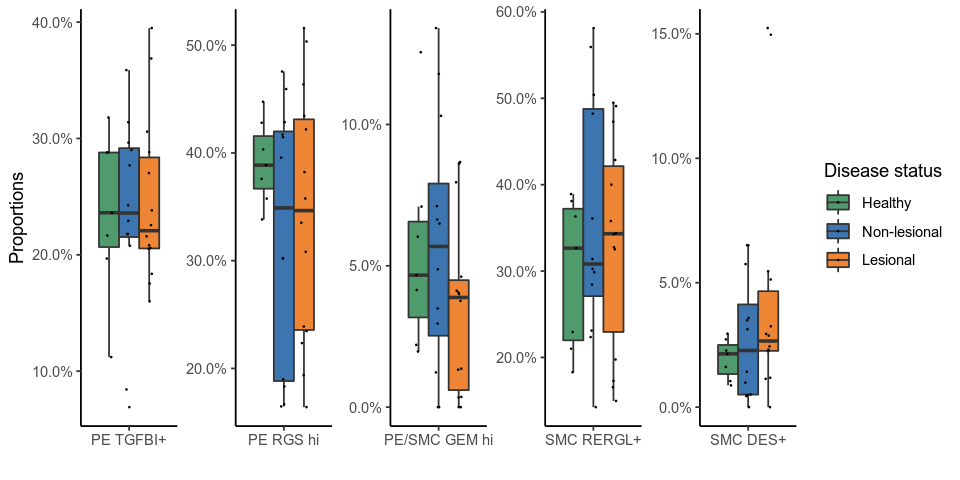

In [100]:
%%R -i peri_pdf -w 8 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(peri_pdf, aes(x=`Cell type granular v2`, y=proportion, fill=disease_lesional)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=disease_lesional), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular v2`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='Disease status')
)
g

## Fig ED9 h,i

In [6]:
import scanpy as sc

In [7]:
atlas = sc.read('/home/gokcen/work/AD-Public/atlas_v3.h5ad')
atlas

AnnData object with n_obs × n_vars = 710704 × 28925
    obs: 'sample_name', 'status', 'Cell type granular preds', 'Cell type granular probs', 'Cell type preds', 'dataset', 'n_genes'
    var: 'Chromosome', 'gene_biotype', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Cell type granular preds_colors', 'Cell type preds_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'status_colors', 'umap'
    obsm: 'X_draw_graph_fr', 'X_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## He study plots

In [9]:
he_study = atlas[atlas.obs['dataset']=='He et al.']
he_study

View of AnnData object with n_obs × n_vars = 39234 × 28925
    obs: 'sample_name', 'status', 'Cell type granular preds', 'Cell type granular probs', 'Cell type preds', 'dataset', 'n_genes', 'lineage'
    var: 'Chromosome', 'gene_biotype', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Cell type granular preds_colors', 'Cell type preds_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'status_colors', 'umap'
    obsm: 'X_draw_graph_fr', 'X_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [45]:
he_study[he_study.obs['Cell type preds']=='Fibroblasts'].obs[['sample_name','status']].drop_duplicates()['status'].value_counts()

Healthy         8
Non-lesional    5
Lesional        4
Name: status, dtype: int64

In [47]:
df = he_study.obs.copy()
df = df[df['Cell type preds'].isin(['DC'])]
df.shape

(1312, 7)

### DC proportions

In [52]:
df = he_study.obs.copy()
df['Cell type preds'] = df['Cell type preds'].astype('category')
df['Cell type granular preds'] = df['Cell type granular preds'].astype('category')

df = df[df['Cell type preds'].isin(['DC'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['sample_name', 'Cell type granular preds', 'status']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['sample_name', 'status'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('sample_name').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='sample_name')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(he_study.obs['Cell type granular preds']):
    proportion_df['Cell type granular preds'] = pd.Categorical(
        proportion_df['Cell type granular preds'],
        categories=he_study.obs['Cell type granular preds'].cat.categories,
        ordered=True
    )
dche_pdf = proportion_df[proportion_df['Cell type granular preds'].isin(['DC MMP12+'])]

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 3 x 3 in image



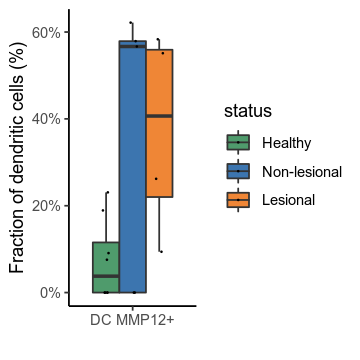

In [53]:
%%R -i dche_pdf -w 3 -h 3 -u in -r 120

library(ggplot2)

g = (
    ggplot(dche_pdf, aes(x=`Cell type granular preds`, y=proportion, fill=status)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=status), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular preds`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of dendritic cells (%)', x='', fill='status')
)

g

In [55]:
df = he_study.obs.copy()
df['Cell type preds'] = df['Cell type preds'].astype('category')
df['Cell type granular preds'] = df['Cell type granular preds'].astype('category')

df = df[df['Cell type preds'].isin(['Fibroblasts'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['sample_name', 'Cell type granular preds', 'status']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['sample_name', 'status'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('sample_name').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='sample_name')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(he_study.obs['Cell type granular preds']):
    proportion_df['Cell type granular preds'] = pd.Categorical(
        proportion_df['Cell type granular preds'],
        categories=he_study.obs['Cell type granular preds'].cat.categories,
        ordered=True
    )
fibhe_pdf = proportion_df[proportion_df['Cell type granular preds'].isin(['FB CCL19+IL4I1+'])]

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


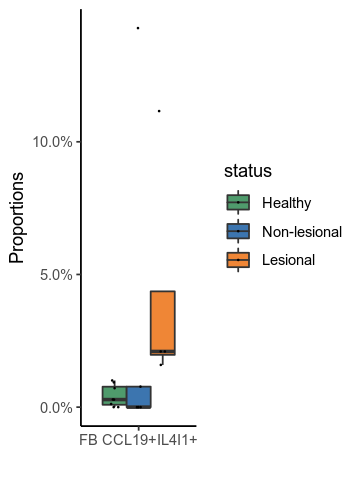

In [56]:
%%R -i fibhe_pdf -w 3 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(fibhe_pdf, aes(x=`Cell type granular preds`, y=proportion, fill=status)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=status), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular preds`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Proportions', x='', fill='status')
)

#ggsave('figures/figure01/proportions-boxplot-keratinocytes.pdf', useDingbats=F)
g

## Rojahn study figs

In [58]:
rojahn_study = atlas[atlas.obs['dataset']=='Rojahn et al.'] 
rojahn_study

View of AnnData object with n_obs × n_vars = 57393 × 28925
    obs: 'sample_name', 'status', 'Cell type granular preds', 'Cell type granular probs', 'Cell type preds', 'dataset', 'n_genes'
    var: 'Chromosome', 'gene_biotype', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Cell type granular preds_colors', 'Cell type preds_colors', 'dataset_colors', 'hvg', 'neighbors', 'pca', 'status_colors', 'umap'
    obsm: 'X_draw_graph_fr', 'X_harmony', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [65]:
#DC MMP12
df = rojahn_study.obs.copy()
df['Cell type preds'] = df['Cell type preds'].astype('category')
df['Cell type granular preds'] = df['Cell type granular preds'].astype('category')

df = df[df['Cell type preds'].isin(['DC'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['sample_name', 'Cell type granular preds', 'status']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['sample_name', 'status'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('sample_name').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='sample_name')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(he_study.obs['Cell type granular preds']):
    proportion_df['Cell type granular preds'] = pd.Categorical(
        proportion_df['Cell type granular preds'],
        categories=he_study.obs['Cell type granular preds'].cat.categories,
        ordered=True
    )
dcrojahn_pdf = proportion_df[proportion_df['Cell type granular preds'].isin(['DC MMP12+'])]

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 3 x 3 in image



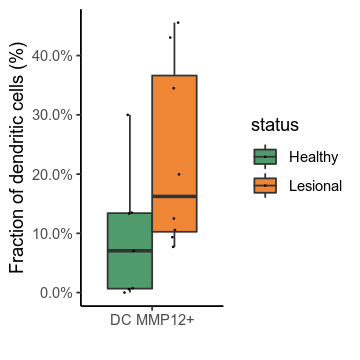

In [66]:
%%R -i dcrojahn_pdf -w 3 -h 3 -u in -r 120

library(ggplot2)

g = (
    ggplot(dcrojahn_pdf, aes(x=`Cell type granular preds`, y=proportion, fill=status)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=status), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular preds`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of dendritic cells (%)', x='', fill='status')
)
g

In [64]:
df = he_study.obs.copy()
df['Cell type preds'] = df['Cell type preds'].astype('category')
df['Cell type granular preds'] = df['Cell type granular preds'].astype('category')

df = df[df['Cell type preds'].isin(['Fibroblasts'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['sample_name', 'Cell type granular preds', 'status']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['sample_name', 'status'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('sample_name').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='sample_name')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(he_study.obs['Cell type granular preds']):
    proportion_df['Cell type granular preds'] = pd.Categorical(
        proportion_df['Cell type granular preds'],
        categories=he_study.obs['Cell type granular preds'].cat.categories,
        ordered=True
    )
fibccl19_pdf = proportion_df[proportion_df['Cell type granular preds'].isin(['FB CCL19+IL4I1+'])]

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
R[write to console]: Saving 3 x 4 in image



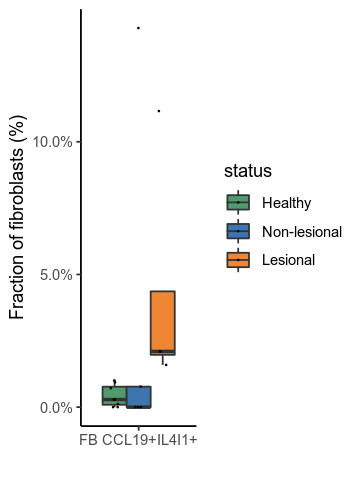

In [130]:
%%R -i fibccl19_pdf -w 3 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(fibccl19_pdf, aes(x=`Cell type granular preds`, y=proportion, fill=status)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=status), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular preds`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C', '#3C75AF',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of fibroblasts (%)', x='', fill='status')
)

g

In [106]:
df = rojahn_study.obs.copy()
df['Cell type preds'] = df['Cell type preds'].astype('category')
df['Cell type granular preds'] = df['Cell type granular preds'].astype('category')

df = df[df['Cell type preds'].isin(['Fibroblasts'])]
# Group by channel, cell type, and disease_lesional to get cell counts
group = df.groupby(['sample_name', 'Cell type granular preds', 'status']).size().reset_index(name='count')
# Compute total counts per channel and disease_lesional to use as denominator
group['total_in_group'] = group.groupby(['sample_name', 'status'])['count'].transform('sum')
group['proportion'] = group['count'] / group['total_in_group']

# For additional covariates, get the total count per channel (across all disease statuses)
covs = df.groupby('sample_name').size().reset_index(name='total_count')

# Merge the proportion data with the overall channel totals
proportion_df = group.merge(covs, on='sample_name')
# Optional: ensure that 'Cell type' remains a categorical variable with the same ordering as in ad.obs
if pd.api.types.is_categorical_dtype(rojahn_study.obs['Cell type granular preds']):
    proportion_df['Cell type granular preds'] = pd.Categorical(
        proportion_df['Cell type granular preds'],
        categories=rojahn_study.obs['Cell type granular preds'].cat.categories,
        ordered=True
    )
fibccl19rojahn_pdf = proportion_df[proportion_df['Cell type granular preds'].isin(['FB CCL19+IL4I1+'])]

/home/gokcen/.miniconda/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:55: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.


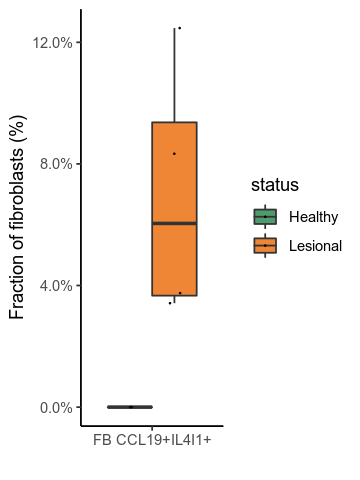

In [109]:
%%R -i fibccl19rojahn_pdf -w 3 -h 4 -u in -r 120

library(ggplot2)

g = (
    ggplot(fibccl19rojahn_pdf, aes(x=`Cell type granular preds`, y=proportion, fill=status)) + 
    geom_boxplot(position='dodge', notch=F, outlier.shape=NA) + 
    geom_point(aes(group=status), position=position_jitterdodge(jitter.width=0.2, jitter.height=0), size=0.1) +    
    facet_wrap(~`Cell type granular preds`, scales='free', nrow=1) + 
    theme_classic() + 
    theme(strip.background=element_blank(), strip.text=element_blank()) + 
    scale_fill_manual(values=c('#4F9B6C',  '#EF8636')) + 
    #scale_y_continuous(trans='log10') + 
    scale_y_continuous(labels = scales::percent) +
    labs(y='Fraction of fibroblasts (%)', x='', fill='status')
)

#ggsave('./tanvi_figures/ed11k_rojahnetal_fbccl19il4l1.pdf', useDingbats=F)
g